# ⚠️ Exposure Anomalies: When the Math Breaks

### Introduction: The Camera is a Liar
Sometimes, you calculate your exposure perfectly, set your camera, and the photo still comes out completely wrong. Why? Because you are working with physical machines and chemical reactions, and they have physical limits.

There are two major "glitches" in photography where you have to bend the rules to get the right exposure:
1. **The Mechanical Glitch:** Leaf Shutter Efficiency (Overexposure).
2. **The Chemical Glitch:** Reciprocity Failure (Underexposure).

---

## 1. The Mechanical Glitch: Leaf Shutter Efficiency
Most modern 35mm cameras use focal-plane shutters (like a curtain dropping). But larger, older cameras use **Leaf Shutters**. A leaf shutter is built right inside the lens. It looks like a mechanical iris made of overlapping metal blades that pull back to let light in, then snap shut.

**The Problem:** The blades do not open and close instantly. It takes a tiny fraction of a second for them to slide open and slide closed. 

If you are shooting on a bright day using a very fast shutter speed (like 1/500th of a second) and a very tiny aperture hole (like f/22), a weird mechanical glitch happens:
* The metal blades begin to pull back.
* Because your aperture hole is so small, the center of the lens is uncovered almost instantly, *long before* the blades finish opening all the way!
* The center of the lens stays exposed the entire time the shutter is struggling to open and close.

**The Result:** The film gets bombarded with light for longer than you intended. Your photo will be **overexposed** (too bright), sometimes by a whole stop! 

**The Fix:** When using a leaf shutter with fast speeds and tiny apertures, you must intentionally close your aperture even more than your light meter tells you to compensate for the extra light leaking in.

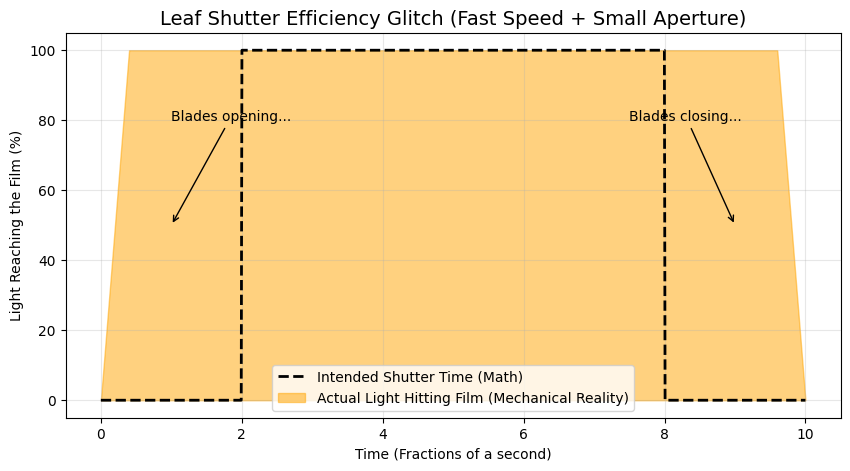

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def simulate_leaf_shutter():
    """
    Simulates why a small aperture gets overexposed on a leaf shutter 
    due to the opening/closing time of the blades.
    """
    time = np.linspace(0, 10, 1000) # Simulating a fast shutter speed (e.g., 1/500s)
    
    # A perfect shutter (square wave): Opens instantly, stays open, closes instantly
    perfect_shutter = np.where((time > 2) & (time < 8), 100, 0)
    
    # A real leaf shutter opening wide (trapezoid): Takes time to open and close
    # The blades travel from 0% open to 100% open
    real_blades_travel = np.interp(time, [0, 2, 8, 10], [0, 100, 100, 0])
    
    # The catch: If we use a TINY aperture (e.g., f/22), the hole is only 20% the size of the lens.
    # Therefore, the hole is completely uncovered when the blades are only 20% open!
    tiny_aperture_limit = 20
    effective_light = np.minimum(real_blades_travel, tiny_aperture_limit)
    
    # Normalize the light to show the percentage of intended exposure
    effective_light_normalized = (effective_light / tiny_aperture_limit) * 100
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot the intended exposure (Perfect physics)
    ax.plot(time, perfect_shutter, 'k--', lw=2, label="Intended Shutter Time (Math)")
    
    # Plot the actual light hitting the film through the tiny aperture
    ax.fill_between(time, effective_light_normalized, color='orange', alpha=0.5, 
                    label="Actual Light Hitting Film (Mechanical Reality)")
    
    ax.set_title("Leaf Shutter Efficiency Glitch (Fast Speed + Small Aperture)", fontsize=14)
    ax.set_xlabel("Time (Fractions of a second)")
    ax.set_ylabel("Light Reaching the Film (%)")
    ax.annotate("Blades opening...", xy=(1, 50), xytext=(1, 80), arrowprops=dict(arrowstyle="->"))
    ax.annotate("Blades closing...", xy=(9, 50), xytext=(7.5, 80), arrowprops=dict(arrowstyle="->"))
    ax.legend(loc="lower center")
    plt.grid(True, alpha=0.3)
    plt.show()

simulate_leaf_shutter()

---

## 2. The Chemical Glitch: Reciprocity Failure
The second anomaly affects *any* camera, because the glitch isn't mechanical; it's chemical. 

In perfect physics, cutting the light in half means you just double the time, and the exposure stays exactly the same. But film chemistry has limits. If you stretch your exposure out too long (usually longer than **1/2 of a second**) or make it too fast (shorter than **1/1000th of a second**), the film stops behaving linearly. 

This is called **Reciprocity Failure**.

### The "Tired Worker" Analogy
Imagine the silver crystals on your film are workers catching buckets of light (photons). 
* In normal daylight, photons are raining down rapidly. The workers catch them easily and build the image.
* But in low light (like a night landscape or using a dense filter), photons drip in very slowly. The workers get "tired" of holding onto a half-finished chemical reaction. The electrons start to escape before the latent image can fully form. 

**The Result:** The film loses its sensitivity. A light meter might tell you to expose the film for 4 seconds. But because the film is "tired," 4 seconds isn't enough. It will come out **underexposed** (too dark). 

**The Fix:** You have to give the film more time than the math says. Every brand of film is slightly different. For example, the manufacturer Ilford provides a specific mathematical curve for their HP5 Plus film to tell you exactly how much extra time to add.

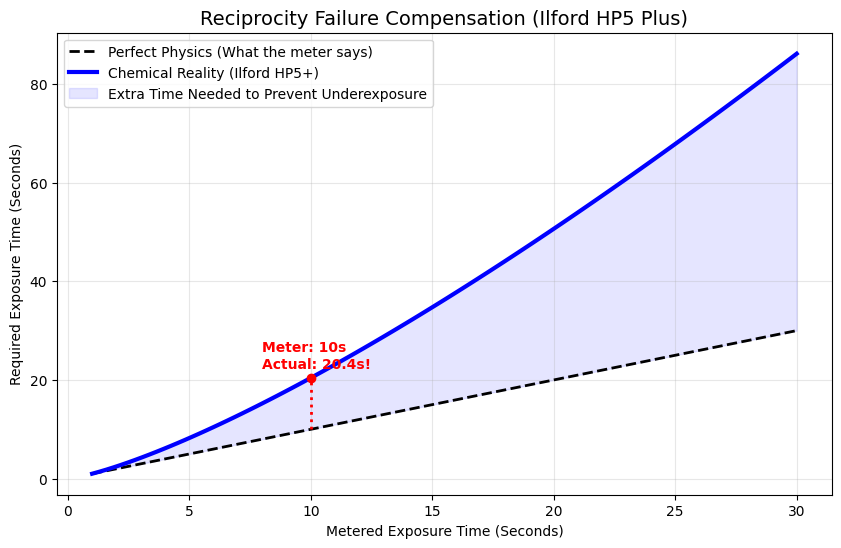

In [3]:
def calculate_ilford_reciprocity():
    """
    Simulates the reciprocity failure compensation curve specifically for Ilford HP5+.
    This compares what the light meter says vs. what you actually have to do.
    """
    # Metered exposure times ranging from 1 second to 30 seconds
    metered_times = np.linspace(1, 30, 100)
    
    # Ilford HP5+ Compensation Formula approximation
    # Actual Time = Metered Time ^ 1.31
    ilford_factor = 1.31
    actual_times = metered_times ** ilford_factor
    
    plt.figure(figsize=(10, 6))
    
    # Plot perfect linear physics
    plt.plot(metered_times, metered_times, 'k--', lw=2, label="Perfect Physics (What the meter says)")
    
    # Plot the chemical reality of HP5+
    plt.plot(metered_times, actual_times, 'b-', lw=3, label="Chemical Reality (Ilford HP5+)")
    
    # Fill the area showing the required compensation
    plt.fill_between(metered_times, metered_times, actual_times, color='blue', alpha=0.1,
                     label="Extra Time Needed to Prevent Underexposure")
    
    # Highlight a specific 10-second example
    meter_10 = 10
    actual_10 = meter_10 ** ilford_factor
    plt.plot([meter_10, meter_10], [meter_10, actual_10], 'r:', lw=2)
    plt.plot(meter_10, actual_10, 'ro')
    plt.text(meter_10 - 2, actual_10 + 2, f"Meter: {meter_10}s\nActual: {actual_10:.1f}s!", color='red', fontweight='bold')
    
    plt.title("Reciprocity Failure Compensation (Ilford HP5 Plus)", fontsize=14)
    plt.xlabel("Metered Exposure Time (Seconds)")
    plt.ylabel("Required Exposure Time (Seconds)")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

calculate_ilford_reciprocity()